# Phase 14: Response Schema

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Define and validate the chatbot response format with answer, sources, confidence, and safety flag.

This notebook imports `07_backend/14_response_schema.py`. The module validates real Phase 12 API responses and adversarial malformed responses using the same canonical response contract.


## Inputs and numbered outputs

**Input**

- `01_data/processed/12_api_responses.json`: real guarded API response payloads from Phase 12.

**Outputs**

- `14_response_validation_results.json`: normalized valid responses and invalid-response errors.
- `14_response_schema_report.json`: totals, configuration, error counts, answer-length statistics, and dependency availability.
- `14_response_schema_audit.csv`: compact validation rows.
- `14_failed_response_schema_checks.json`: invalid response numbers and validation errors.
- `plots/14_answer_length_distribution.png`: answer length distribution.
- `plots/14_response_validation_outcomes.png`: valid versus invalid response counts.


In [8]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = []
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "07_backend" / "14_response_schema.py"
        responses_path = candidate / "01_data" / "processed" / "12_api_responses.json"
        if module_path.is_file() and responses_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "07_backend" / "14_response_schema.py"
RESPONSES_PATH = PROJECT_ROOT / "01_data" / "processed" / "12_api_responses.json"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase14_response_schema", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
response_schema = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = response_schema
spec.loader.exec_module(response_schema)

print(f"Project root: {PROJECT_ROOT}")
print(f"Response schema module: {MODULE_PATH}")
print(f"Pydantic available: {importlib.util.find_spec('pydantic') is not None}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Response schema module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\07_backend\14_response_schema.py
Pydantic available: False


## Canonical response contract

The schema validates request ID, answer text, response mode, citations, source records, retrieval confidence, safety flag, guardrail action, risk level, triggered rules, provider, model, latency, and timestamp. Grounded answers with sources must cite their own source labels.


In [9]:
responses = response_schema.load_api_responses(RESPONSES_PATH)
config = response_schema.ResponseValidationConfig()
valid_result = response_schema.validate_response_payload(responses[0], config)

assert valid_result.valid is True
assert valid_result.normalized_response.citations
assert valid_result.normalized_response.sources

print(json.dumps(valid_result.__dict__, default=lambda value: value.__dict__, indent=2))


{
  "response_number": 1,
  "valid": true,
  "normalized_response": {
    "request_id": "REQ-841C631E6B55",
    "answer": "Use the patient portal, call 555-0101, or visit the Appointments Desk. Same-day availability is not guaranteed. [S1]",
    "mode": "grounded_answer",
    "citations": [
      "[S1]"
    ],
    "sources": [
      {
        "citation": "[S1]",
        "source_file": "faqs/hospital_faqs.json",
        "chunk_id": "faqs-hospital-faqs-json-0001-chunk-001",
        "source_type": "json",
        "department": "Portal Support",
        "content_category": "appointments",
        "page_reference": "None",
        "score": 0.74580427
      },
      {
        "citation": "[S2]",
        "source_file": "faqs/hospital_faqs.json",
        "chunk_id": "faqs-hospital-faqs-json-0003-chunk-001",
        "source_type": "json",
        "department": "Billing and Insurance",
        "content_category": "appointments",
        "page_reference": "None",
        "score": 0.54794383
     

## Invalid response examples

Malformed examples reject empty answers, unsupported citations, missing grounded citations, inconsistent safety flags, negative latency, and unknown confidence labels.


In [10]:
for number, payload in enumerate(response_schema.adversarial_responses(responses[0]), start=1):
    invalid = response_schema.validate_response_payload(payload, config, response_number=number)
    assert invalid.valid is False
    print(f"Case {number}: {invalid.errors}")


Case 1: ['answer must not be empty.']
Case 2: ['citations not present in sources: [S9].']
Case 3: ['grounded answers with sources must include citations.']
Case 4: ['non-pass guardrail actions must set safety_flag to true.', 'non-safety responses must not include triggered_rules.']
Case 5: ['latency_ms must not be negative.']
Case 6: ['retrieval_confidence is not recognized.']


## Optional Pydantic model

When Pydantic is installed, the module can create response models for FastAPI/OpenAPI. The current interpreter reports availability explicitly without failing the notebook.


In [11]:
if importlib.util.find_spec("pydantic") is not None:
    ResponseModel = response_schema.create_pydantic_response_model()
    model = ResponseModel(**responses[0])
    assert model.request_id == responses[0]["request_id"]
    print(ResponseModel)
else:
    try:
        response_schema.create_pydantic_response_model()
    except RuntimeError as error:
        print(f"Expected dependency message: {error}")


Expected dependency message: Pydantic is not installed. Install requirements.txt to create the FastAPI response model.


## Run full Phase 14 validation

The batch validates 12 real Phase 12 API responses and 6 adversarial response-shape cases. The expected result is 12 valid responses and 6 invalid responses.


In [12]:
batch_result = response_schema.run_response_schema_validation(RESPONSES_PATH, OUTPUT_DIR, config)

assert batch_result.input_responses == 18
assert batch_result.valid_responses == 12
assert batch_result.invalid_responses == 6

print(f"Input responses: {batch_result.input_responses}")
print(f"Valid responses: {batch_result.valid_responses}")
print(f"Invalid responses: {batch_result.invalid_responses}")


Input responses: 18
Valid responses: 12
Invalid responses: 6


## Validate artifacts

The report records dependency availability, response totals, answer-length statistics, and error counts. The failure file contains only invalid response numbers and validation messages.


In [13]:
results = json.loads(batch_result.results_path.read_text(encoding="utf-8"))
report = json.loads(batch_result.report_path.read_text(encoding="utf-8"))
failures = json.loads(batch_result.failed_path.read_text(encoding="utf-8"))

assert len(results) == 18
assert len(failures) == 6
assert report["valid_responses"] == 12
assert report["invalid_responses"] == 6
assert report["pydantic_available"] is False

print(json.dumps(report, indent=2))


{
  "generated_at_utc": "2026-06-15T19:53:40.494889+00:00",
  "schema_version": "1.0",
  "input_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\12_api_responses.json",
  "input_responses": 18,
  "real_api_responses": 12,
  "adversarial_responses": 6,
  "valid_responses": 12,
  "invalid_responses": 6,
  "pydantic_available": false,
  "configuration": {
    "max_answer_characters": 2500,
    "max_sources": 6,
    "require_citations_for_grounded_answers": true
  },
  "answer_characters": {
    "minimum": 0,
    "maximum": 158,
    "mean": 117.889,
    "median": 116.0
  },
  "error_counts": {
    "answer must not be empty.": 1,
    "citations not present in sources: [S9].": 1,
    "grounded answers with sources must include citations.": 1,
    "latency_ms must not be negative.": 1,
    "non-pass guardrail actions must set safety_flag to true.": 1,
    "non-safety responses must not include triggered_rules.": 1,

## Diagnostic plots

The length plot helps tune answer-size limits. The outcome plot verifies real API responses pass while adversarial malformed payloads fail.


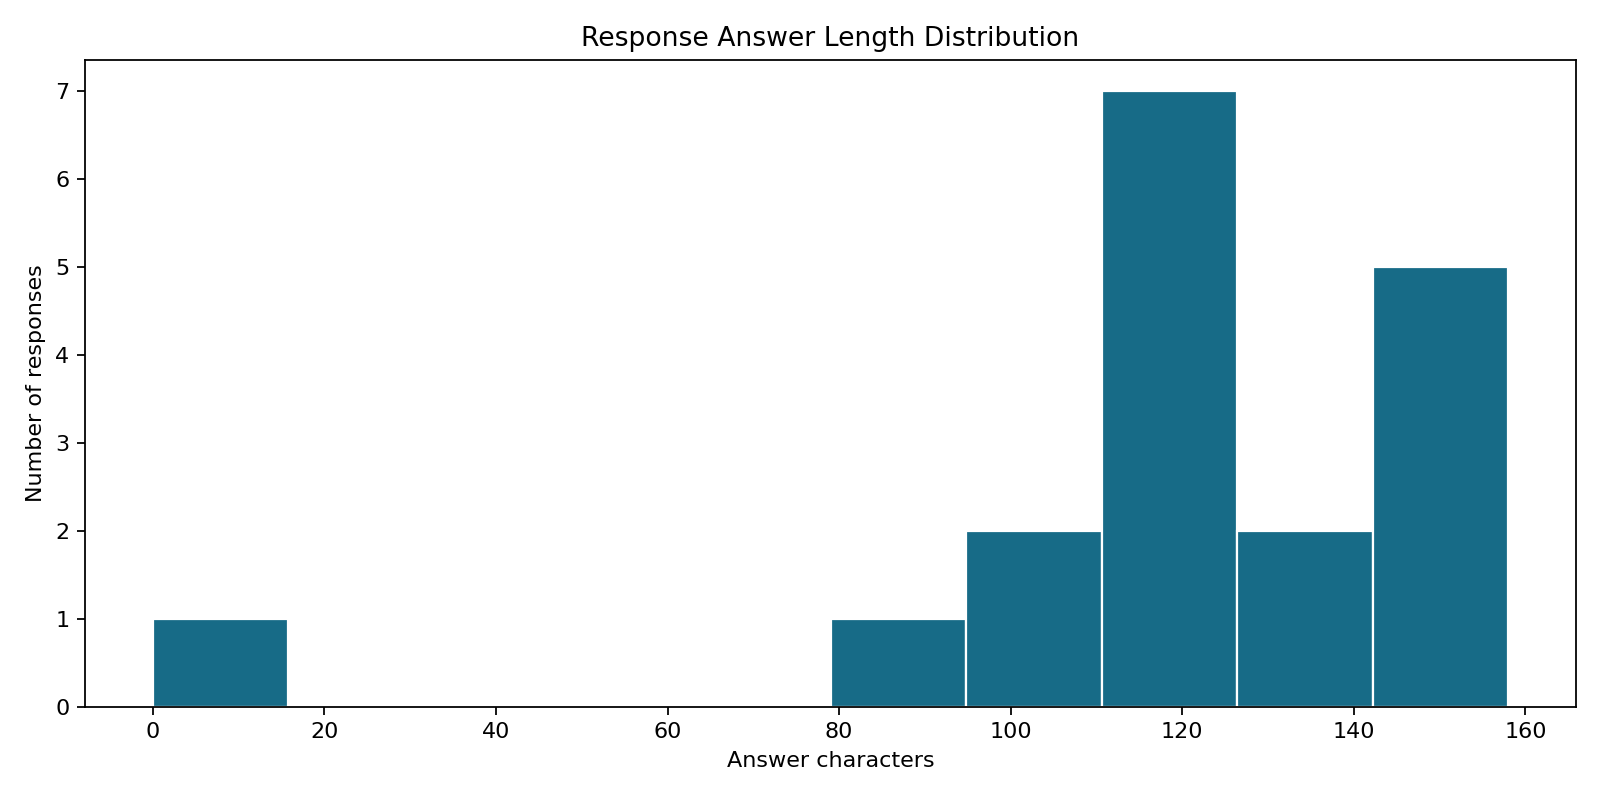

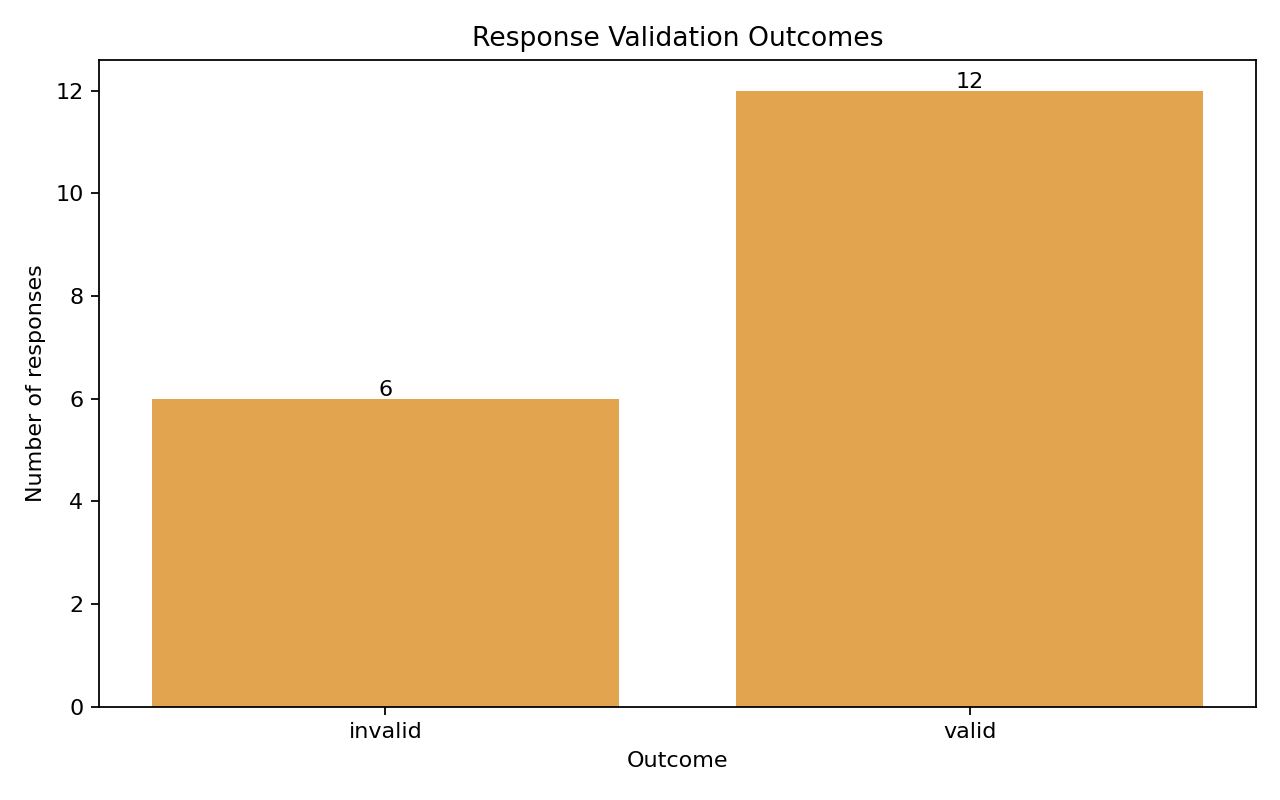

In [14]:
from IPython.display import Image, display

display(Image(filename=str(batch_result.length_plot_path)))
display(Image(filename=str(batch_result.outcomes_plot_path)))


## Notebook and Python module responsibilities

- **Notebook:** explains the contract, demonstrates valid and invalid responses, checks optional Pydantic support, validates artifacts, and displays plots.
- **Python module:** owns response dataclasses, source validation, citation checks, safety-flag consistency, optional Pydantic model creation, batch artifacts, plots, and CLI automation.

Both files use the same validation functions, keeping the notebook aligned with the Python module.
